_____

<table align="left" width=100%>
    <td>
        <div style="text-align: center;">
          <img src="../../images/bar.png" alt="entidades financiadoras"/>
        </div>
    </td>
    <td>
        <p style="text-align: center; font-size:24px;"><b>Introduction to Data Science</b></p>
        <p style="text-align: center; font-size:18px;"><b>Master in Electrical and Computer Engineering</b></p>
        <p style="text-align: center; font-size:14px;"><b>Pedro Cardoso (pcardoso@ualg.pt)</b></p>
    </td>
</table>

_____

**Draft Solutions:** Pandas Series

# Pandas Series — Draft Solutions

> These are **draft solutions** intended for instructors. Students should attempt the exercises independently before consulting these solutions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---

## 1. Creating a Series

**Exercise 1.1** — Create an empty `Series` with `dtype='float64'` and print it.

In [2]:
s = pd.Series(dtype='float64')
print(s)

Series([], dtype: float64)


**Exercise 1.2** — Create a `Series` from the list `[10, 20, 30, 40, 50]` using the default integer index. Display it.

In [3]:
s = pd.Series([10, 20, 30, 40, 50])
s

0    10
1    20
2    30
3    40
4    50
dtype: int64

**Exercise 1.3** — Generate a NumPy array of 6 random standard-normal values and create a `Series` from it, using the letters `['p', 'q', 'r', 's', 't', 'u']` as the index.

In [4]:
v = np.random.normal(size=6)
s = pd.Series(v, index=['p', 'q', 'r', 's', 't', 'u'])
s

p    0.873464
q   -1.315420
r    1.905513
s   -0.688088
t    1.548021
u   -0.712735
dtype: float64

**Exercise 1.4** — Create a `Series` from the following dictionary:

```python
{'apple': 3, 'banana': 7, 'cherry': 2, 'date': 5}
```

In [5]:
s = pd.Series({'apple': 3, 'banana': 7, 'cherry': 2, 'date': 5})
s

apple     3
banana    7
cherry    2
date      5
dtype: int64

**Exercise 1.5** — Create a `Series` where every element has the value `3.14`, using the index `['x', 'y', 'z']`.

In [6]:
s = pd.Series(3.14, index=['x', 'y', 'z'])
s

x    3.14
y    3.14
z    3.14
dtype: float64

---

## 2. Accessing Data

In [7]:
np.random.seed(42)
s = pd.Series(np.random.normal(size=5), index=list('abcde'))
s

a    0.496714
b   -0.138264
c    0.647689
d    1.523030
e   -0.234153
dtype: float64

**Exercise 2.1** — Display the index of `s`.

In [8]:
s.index

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')

**Exercise 2.2** — Display the underlying NumPy array of values in `s`.

In [9]:
s.values

array([ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337])

**Exercise 2.3** — Access the value at label `'c'` using three different approaches.

In [10]:
# dot notation
print(s.c)

# key access
print(s['c'])

# .loc
print(s.loc['c'])

0.6476885381006925
0.6476885381006925
0.6476885381006925


**Exercise 2.4** — Access the value at position 2 (0-based) using `.iloc`.

In [11]:
s.iloc[2]

np.float64(0.6476885381006925)

**Exercise 2.5** — Retrieve the slice from label `'b'` to label `'d'` (inclusive).

In [12]:
# Label-based slicing with [] is inclusive of both endpoints
s['b':'d']

b   -0.138264
c    0.647689
d    1.523030
dtype: float64

**Exercise 2.6** — Retrieve the last 3 elements of `s` using `.iloc`.

In [13]:
s.iloc[-3:]

c    0.647689
d    1.523030
e   -0.234153
dtype: float64

**Exercise 2.7** — Retrieve the elements at labels `'a'`, `'c'`, and `'e'` in a single call.

In [14]:
s[['a', 'c', 'e']]

a    0.496714
c    0.647689
e   -0.234153
dtype: float64

---

## 3. Unique vs Non-unique Indexes

**Exercise 3.1** — Create a `Series` with value `0.5` for each letter in `'mississippi'`. Access all elements at label `'s'`.

In [15]:
s = pd.Series(0.5, index=tuple('mississippi'))
s['s']

# 'mississippi' contains 4 's' characters, so 4 values are returned.
# When the index is non-unique, pandas cannot return a scalar;
# it returns a Series containing all matching elements.

s    0.5
s    0.5
s    0.5
s    0.5
dtype: float64

**Exercise 3.2** — Compare access time for label `'i'` on unsorted vs sorted versions of the Series.

In [16]:
s_non_unique = pd.Series(0.5, index=tuple('mississippi'))

print("Unsorted")
%timeit s_non_unique['i']

print("Sorted")
s_sorted = s_non_unique.sort_index()
%timeit s_sorted['i']

# The sorted version should be faster.
# With a non-unique unsorted index pandas must do a linear scan O(N).
# With a non-unique sorted index pandas can use binary search O(log N).

Unsorted
23.5 μs ± 1.15 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Sorted
9.66 μs ± 900 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


---

## 4. Missing Values (NaN)

**Exercise 4.1** — Create a `Series` from a dict with index `['a', 'b', 'c', 'd', 'e']`.

In [17]:
s = pd.Series({'a': 1, 'b': 2, 'c': 3}, index=['a', 'b', 'c', 'd', 'e'])
s

# Labels 'd' and 'e' are not present in the dict, so pandas fills them with NaN.

a    1.0
b    2.0
c    3.0
d    NaN
e    NaN
dtype: float64

**Exercise 4.2** — Produce a boolean mask that is `True` where values are `NaN`.

In [18]:
s.isna()

a    False
b    False
c    False
d     True
e     True
dtype: bool

**Exercise 4.3** — Count the number of missing values.

In [19]:
s.isna().sum()

np.int64(2)

---

## 5. Data Types

**Exercise 5.1** — Compare the `dtype` of an integer list vs a float list.

In [20]:
s_int = pd.Series([1, 2, 3, 4, 5])
s_float = pd.Series([1.0, 2.0, 3.0])

print('Integer list dtype:', s_int.dtype)   # int64
print('Float list dtype:  ', s_float.dtype)  # float64

# pandas infers the dtype from the values:
# a list of Python ints produces int64; a list of Python floats produces float64.

Integer list dtype: int64
Float list dtype:   float64


**Exercise 5.2** — Create a `Series` from a mixed-type list and inspect `dtype`.

In [21]:
s_mixed = pd.Series([1, 'two', 3.0, True])
print(s_mixed)
print('dtype:', s_mixed.dtype)

# When a list contains mixed types that cannot be cast to a single numeric type,
# pandas falls back to dtype='object', which stores arbitrary Python objects.

0       1
1     two
2     3.0
3    True
dtype: object
dtype: object


**Exercise 5.3** — Compare the type of `s.values` vs `s.array`.

In [22]:
s = pd.Series([1.0, 2.0, 3.0], index=list('abc'))

print('type(s.values):', type(s.values))  # numpy.ndarray
print('type(s.array): ', type(s.array))   # pandas NumpyExtensionArray

# s.values returns a plain NumPy ndarray — useful for interoperability with NumPy.
# s.array returns a pandas ExtensionArray, which can represent richer types
# (e.g. nullable integers, categoricals) that NumPy does not natively support.

type(s.values): <class 'numpy.ndarray'>
type(s.array):  <class 'pandas.core.arrays.numpy_.NumpyExtensionArray'>


---

## 6. Filtering and Selection

In [23]:
np.random.seed(0)
s = pd.Series(np.random.normal(size=10), index=list('abcdefghij'))
s

a    1.764052
b    0.400157
c    0.978738
d    2.240893
e    1.867558
f   -0.977278
g    0.950088
h   -0.151357
i   -0.103219
j    0.410599
dtype: float64

**Exercise 6.1** — Select all elements that are negative.

In [24]:
s[s < 0]

f   -0.977278
h   -0.151357
i   -0.103219
dtype: float64

**Exercise 6.2** — Select all elements whose absolute value is greater than 1.

In [25]:
s[s.abs() > 1]

a    1.764052
d    2.240893
e    1.867558
dtype: float64

**Exercise 6.3** — Select elements between the 25th and 75th percentiles (interquartile range).

In [26]:
q25 = s.quantile(0.25)
q75 = s.quantile(0.75)
s[(s >= q25) & (s <= q75)]

b    0.400157
c    0.978738
g    0.950088
j    0.410599
dtype: float64

**Exercise 6.4** — Select the first 4 and last 3 elements by position and concatenate them.

In [27]:
pd.concat([s.iloc[:4], s.iloc[-3:]])

a    1.764052
b    0.400157
c    0.978738
d    2.240893
h   -0.151357
i   -0.103219
j    0.410599
dtype: float64

**Exercise 6.5** — Select labels `'b'`, `'e'`, and `'h'` with a single `loc` call.

In [28]:
s.loc[['b', 'e', 'h']]

b    0.400157
e    1.867558
h   -0.151357
dtype: float64

---

## 7. Modifying Data

In [29]:
s = pd.Series([1.0, 2.0, 3.0, 4.0, 5.0], index=list('abcde'))
s

a    1.0
b    2.0
c    3.0
d    4.0
e    5.0
dtype: float64

**Exercise 7.1** — Set the value at label `'c'` to `99.0` using `.loc`.

In [30]:
s.loc['c'] = 99.0
s

a     1.0
b     2.0
c    99.0
d     4.0
e     5.0
dtype: float64

**Exercise 7.2** — Set the last two elements to `0.0` using `.iloc`.

In [31]:
s.iloc[-2:] = 0.0
s

a     1.0
b     2.0
c    99.0
d     0.0
e     0.0
dtype: float64

**Exercise 7.3** — Double the value of all elements currently greater than `2.0`.

In [32]:
s = pd.Series([1.0, 2.0, 3.0, 4.0, 5.0], index=list('abcde'))
s[s > 2.0] *= 2
s

a     1.0
b     2.0
c     6.0
d     8.0
e    10.0
dtype: float64

---

## 8. Vectorised Operations

**Exercise 8.1** — Compute element-wise sum, difference, and product of two aligned Series.

In [33]:
r = pd.Series([10, 20, 30, 40], index=list('abcd'))
s = pd.Series([1, 2, 3, 4], index=list('abcd'))

print('Sum:\n', r + s)
print('\nDifference:\n', r - s)
print('\nProduct:\n', r * s)

Sum:
 a    11
b    22
c    33
d    44
dtype: int64

Difference:
 a     9
b    18
c    27
d    36
dtype: int64

Product:
 a     10
b     40
c     90
d    160
dtype: int64


**Exercise 8.2** — Sum two Series with partially overlapping indexes and explain the `NaN` values.

In [34]:
r = pd.Series([1, 2, 3], index=list('abc'))
s = pd.Series([10, 20, 30], index=list('bcd'))

r + s

# pandas aligns by index label before operating.
# Label 'a' exists only in r; label 'd' exists only in s.
# When a label is missing in one Series, the result is NaN for that position.
# Labels 'b' and 'c' exist in both, so those positions are computed normally.

a     NaN
b    12.0
c    23.0
d     NaN
dtype: float64

**Exercise 8.3** — Apply square, square root, and exponential to a Series.

In [35]:
s = pd.Series([1, 2, 3, 4, 5])

print('Square:\n', s ** 2)
print('\nSquare root:\n', np.sqrt(s))
print('\nExponential:\n', np.exp(s))

Square:
 0     1
1     4
2     9
3    16
4    25
dtype: int64

Square root:
 0    1.000000
1    1.414214
2    1.732051
3    2.000000
4    2.236068
dtype: float64

Exponential:
 0      2.718282
1      7.389056
2     20.085537
3     54.598150
4    148.413159
dtype: float64


**Exercise 8.4** — Add a `Series` to a shifted version of itself and explain the `NaN` values.

In [36]:
s = pd.Series([10, 20, 30, 40, 50], index=list('abcde'))

s.iloc[1:] + s.iloc[:-1]

# s.iloc[1:] has labels b,c,d,e  (drops 'a')
# s.iloc[:-1] has labels a,b,c,d (drops 'e')
# 'a' only appears in the second operand → NaN
# 'e' only appears in the first operand  → NaN
# 'b', 'c', 'd' appear in both           → computed normally

a     NaN
b    40.0
c    60.0
d    80.0
e     NaN
dtype: float64

---

## 9. Describing and Visualising Data

**Exercise 9.1** — Create a 500-sample uniform Series and summarise it.

In [37]:
np.random.seed(1)
s_uniform = pd.Series(np.random.uniform(0, 10, size=500))
s_uniform.describe()

# The mean should be close to 5 (midpoint of [0, 10]).
# min ≈ 0, max ≈ 10, and the quartiles should be evenly spaced (~2.5, 5, 7.5),
# reflecting the flat shape of the uniform distribution.

count    500.000000
mean       5.082771
std        2.968271
min        0.001144
25%        2.493964
50%        5.334093
75%        7.672182
max        9.973229
dtype: float64

**Exercise 9.2** — Plot a histogram of the uniform Series with 30 bins.

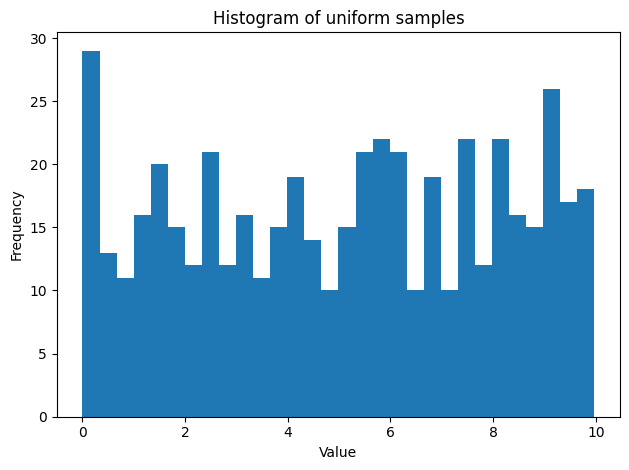

In [38]:
s_uniform.plot(kind='hist', bins=30)
plt.title('Histogram of uniform samples')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Exercise 9.3** — Overlay the normalised histogram and the KDE curve.

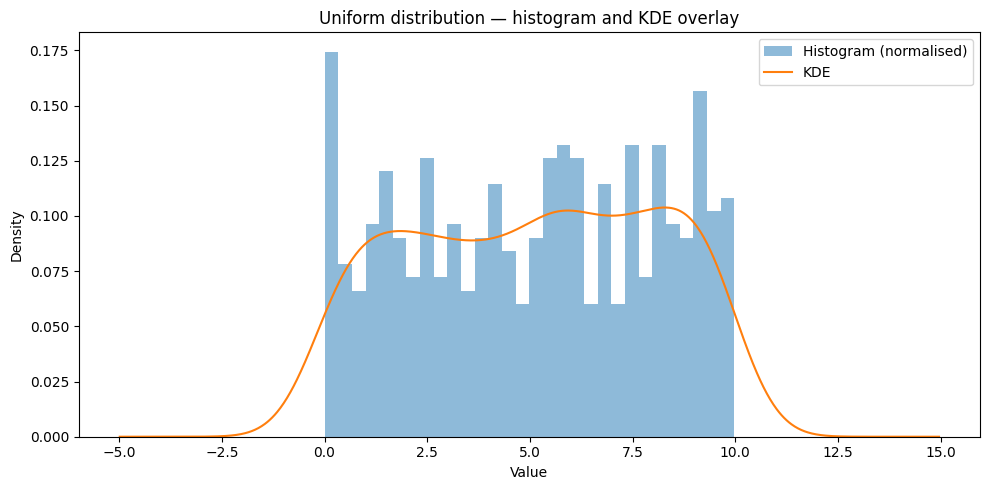

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
s_uniform.plot(kind='hist', bins=30, density=True, alpha=0.5,
               label='Histogram (normalised)', ax=ax)
s_uniform.plot(kind='kde', label='KDE', ax=ax)
ax.set_title('Uniform distribution — histogram and KDE overlay')
ax.set_xlabel('Value')
ax.legend()
plt.tight_layout()
plt.show()

# The KDE of a uniform distribution should be approximately flat (rectangular).
# The slight curvature near the edges is a known boundary effect of kernel smoothing.

**Exercise 9.4** — Plot KDE curves for two normal distributions on the same axes.

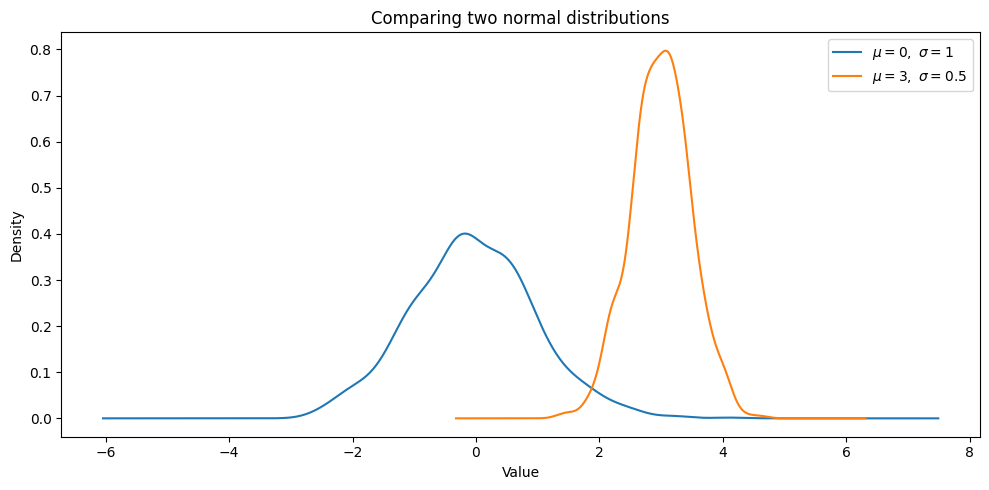

In [40]:
np.random.seed(2)
s1 = pd.Series(np.random.normal(loc=0, scale=1, size=1000))
s2 = pd.Series(np.random.normal(loc=3, scale=0.5, size=1000))

fig, ax = plt.subplots(figsize=(10, 5))
s1.plot(kind='kde', ax=ax, label=r'$\mu=0,\ \sigma=1$')
s2.plot(kind='kde', ax=ax, label=r'$\mu=3,\ \sigma=0.5$')
ax.set_title('Comparing two normal distributions')
ax.set_xlabel('Value')
ax.legend()
plt.tight_layout()
plt.show()

# s2 is narrower (smaller σ → more concentrated) and shifted to the right (larger μ).

**Exercise 9.5** — Plot daily temperatures as a line and bar chart in a 1×2 subplot.

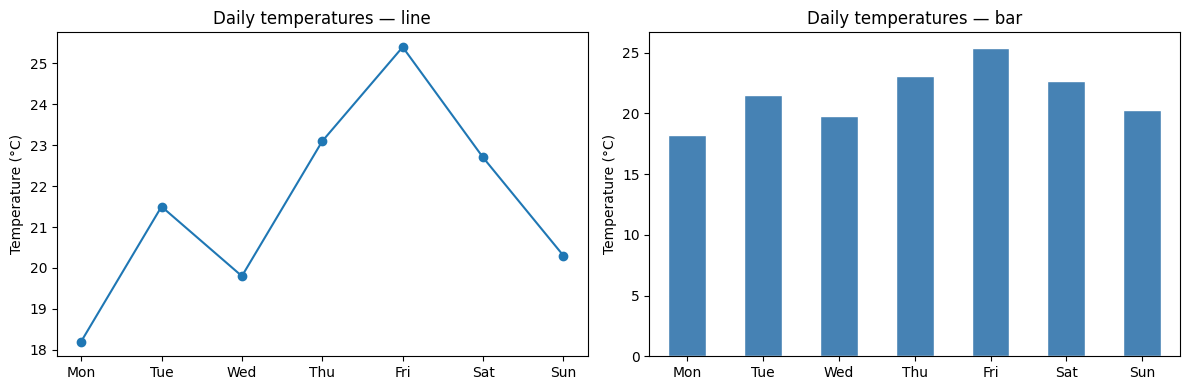

In [41]:
temps = pd.Series([18.2, 21.5, 19.8, 23.1, 25.4, 22.7, 20.3],
                  index=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

temps.plot(ax=axes[0], marker='o', title='Daily temperatures — line')
axes[0].set_ylabel('Temperature (°C)')

temps.plot(kind='bar', ax=axes[1], color='steelblue',
           edgecolor='white', title='Daily temperatures — bar')
axes[1].set_ylabel('Temperature (°C)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()